In [38]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from src.data_add_column import  add_era_to_all, add_round_group, round_group_summary, add_era_column
from src.step1_functions import filter_country, add_derived_metrics 
from src.step2_functions import country_match_aggregates, country_depth_aggregates, country_competition_breakdown, build_composite
from src.step3_functions import italy_by_competition

In [39]:
# loading data
CHARTS_DIR    = "../charts/"
PROCESSED_DIR = "../data/processed/"

ge = pd.read_pickle(f"{PROCESSED_DIR}ge.pkl")
by_comp = pd.read_pickle(f"{PROCESSED_DIR}by_comp.pkl")



In [40]:
# Correct — full country_stats with era labels added
cs_full = pd.read_pickle("../data/processed/country_stats_complete.pkl")
cs_full = add_era_column(cs_full)   # from step0_era

italy_cs, italy_csh = filter_country(cs_full, 
                                      pd.read_pickle("../data/processed/country_season_highest.pkl"),
                                      country_name="Ita")
italy_cs = add_derived_metrics(italy_cs)


  Filtering to: Ita
  country_stats          rows : 57
  country_season_highest rows : 57
  country_stats era breakdown:
      Pre-Golden Era        : 18 seasons
      Golden Era            : 17 seasons
      Post-Golden Era       : 22 seasons

  Derived metrics preview (first 5 rows):
 season            era  num_teams  win_rate  ppg3_pt  gdpg_pt
1969/70 Pre-Golden Era          7  0.523810 0.258503 0.064626
1970/71 Pre-Golden Era          6  0.423077 0.269231 0.102564
1971/72 Pre-Golden Era          6  0.461538 0.282051 0.145299
1972/73 Pre-Golden Era          6  0.593750 0.328125 0.119792
1973/74 Pre-Golden Era          6  0.428571 0.238095 0.015873


In [26]:
italy_cs.head()

,country,season,num_teams,wins,draws,losses,goals_for,goals_against,total_matches,win_rate,draw_rate,loss_rate,ppg_3,ppg_2,goal_diff,gf_pg,ga_pg,gdpg,era
0,Ita,1987/88,6,13,8,11,42.0,28.0,32,0.406250,0.250000,0.343750,1.468750,1.062500,14.0,1.312500,0.875000,0.437500,Golden Era
1,Ita,1988/89,6,25,13,12,83.0,49.0,50,0.500000,0.260000,0.240000,1.760000,1.260000,34.0,1.660000,0.980000,0.680000,Golden Era
2,Ita,1989/90,7,27,16,9,61.0,35.0,52,0.519231,0.307692,0.173077,1.865385,1.346154,26.0,1.173077,0.673077,0.500000,Golden Era
3,Ita,1990/91,8,35,15,12,95.0,42.0,62,0.564516,0.241935,0.193548,1.935484,1.370968,53.0,1.532258,0.677419,0.854839,Golden Era
4,Ita,1991/92,6,21,13,9,69.0,36.0,43,0.488372,0.302326,0.209302,1.767442,1.279070,33.0,1.604651,0.837209,0.767442,Golden Era


In [41]:
match_agg = country_match_aggregates(ge["cs"])
depth_agg = country_depth_aggregates(ge["csh"])
_, pivot = country_competition_breakdown(ge["csch"])
rankings = build_composite(match_agg, depth_agg)
comp_summary = italy_by_competition(by_comp, country_name="Ita")


  Gib, Kaz, Kos, Mon, Sma

  Per-country match aggregates (Golden Era) — top 10 by win rate
    #  Country               Seasons   Win rate   PPG/team   GDpG/team
  -----------------------------------------------------------------
    1  Ita                        13      0.545      0.275       0.114
    2  Esp                        13      0.517      0.299       0.110
    3  Ger                        13      0.498      0.264       0.096
    4  Fra                        13      0.492      0.310       0.111
    5  YUG                        13      0.482      0.389       0.093
    6  Svk                        13      0.476      0.490      -0.019
    7  Eng                        13      0.464      0.383       0.141
    8  Geo                        13      0.439      0.896      -0.089
    9  Ukr                        13      0.439      0.455       0.003
   10  Rus                        13      0.427      0.332       0.028

  Italy  →  rank #1 of 59 countries  (win rate 0.545)
  [

In [29]:
italy_cs

,country,season,num_teams,wins,draws,losses,goals_for,goals_against,total_matches,win_rate,...,ppg_3,ppg_2,goal_diff,gf_pg,ga_pg,gdpg,era,ppg3_pt,ppg2_pt,gdpg_pt
0,Ita,1987/88,6,13,8,11,42.0,28.0,32,0.406250,...,1.468750,1.062500,14.0,1.312500,0.875000,0.437500,Golden Era,0.244792,0.177083,0.072917
1,Ita,1988/89,6,25,13,12,83.0,49.0,50,0.500000,...,1.760000,1.260000,34.0,1.660000,0.980000,0.680000,Golden Era,0.293333,0.210000,0.113333
2,Ita,1989/90,7,27,16,9,61.0,35.0,52,0.519231,...,1.865385,1.346154,26.0,1.173077,0.673077,0.500000,Golden Era,0.266484,0.192308,0.071429
3,Ita,1990/91,8,35,15,12,95.0,42.0,62,0.564516,...,1.935484,1.370968,53.0,1.532258,0.677419,0.854839,Golden Era,0.241935,0.171371,0.106855
4,Ita,1991/92,6,21,13,9,69.0,36.0,43,0.488372,...,1.767442,1.279070,33.0,1.604651,0.837209,0.767442,Golden Era,0.294574,0.213178,0.127907
5,Ita,1992/93,6,33,6,9,92.0,29.0,48,0.687500,...,2.187500,1.500000,63.0,1.916667,0.604167,1.312500,Golden Era,0.364583,0.250000,0.218750
6,Ita,1993/94,7,37,11,13,93.0,42.0,61,0.606557,...,2.000000,1.393443,51.0,1.524590,0.688525,0.836066,Golden Era,0.285714,0.199063,0.119438
7,Ita,1994/95,7,35,10,14,85.0,44.0,59,0.593220,...,1.949153,1.355932,41.0,1.440678,0.745763,0.694915,Golden Era,0.278450,0.193705,0.099274
8,Ita,1995/96,6,22,6,11,72.0,34.0,39,0.564103,...,1.846154,1.282051,38.0,1.846154,0.871795,0.974359,Golden Era,0.307692,0.213675,0.162393
9,Ita,1996/97,7,26,9,12,77.0,47.0,47,0.553191,...,1.851064,1.297872,30.0,1.638298,1.000000,0.638298,Golden Era,0.264438,0.185410,0.091185


## Plot 1: Golden Era results vs Pre and Post era



Let's startu with a line chart of Italy's `win_rate` and `gdpg_pt` across all seasons in the data (not just Golden Era), with the three era periods shaded as background bands. This is the "big picture", comparing the pre, post and era results.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# ── Era labels (single source of truth) ──────────────────────────────────────
ERA_PRE    = "Pre-Golden Era"
ERA_GOLDEN = "Golden Era"
ERA_POST   = "Post-Golden Era"

# Ordered list – useful for sorting / CategoricalDtype later
ERA_ORDER = [ERA_PRE, ERA_GOLDEN, ERA_POST]

# -- Palette ------------------------------------------------------------------
DARK_BG      = "#1C1C1C"
PANEL_BG     = "#242424"
ITALY_BLUE   = "#4C9BE8"
GOLD_COLOR   = "#D4AF37"
GRID_COLOR   = "#333333"
TEXT_COLOR   = "#E0E0E0"
SUBTEXT      = "#999999"

ERA_BAND_COLORS = {
    "Pre-Golden Era" : "#555555",
    "Golden Era"     : "#D4AF37",
    "Post-Golden Era": "#C0392B",
}

METRICS = [
    ("win_rate", "Win rate"),
    ("gdpg_pt",  "Goal difference per game per team"),
]


def plot_italy_season_trend(
    italy_cs:   pd.DataFrame,
    charts_dir: str  = "../charts/",
    country_name: str = "Ita",
    filename:   str  = "4a_italy_season_trend.png",
    dpi:        int  = 150,
) -> None:
    """
    Plot Italy's win_rate and gdpg_pt across all seasons with era bands.

    Parameters
    ----------
    italy_cs     : Italy country_stats with 'era', 'win_rate', 'gdpg_pt'
    charts_dir   : output folder  (default '../charts/')
    country_name : label used in chart title
    filename     : output filename
    dpi          : image resolution
    """
    # -- Validate columns -----------------------------------------------------
    for col in ["season", "era", "win_rate", "gdpg_pt"]:
        if col not in italy_cs.columns:
            raise KeyError(f"Column '{col}' missing from italy_cs. "
                           f"Run filter_country + add_derived_metrics first.")

    # -- Sort seasons chronologically -----------------------------------------
    df = italy_cs.copy()
    df["_yr"] = df["season"].apply(
        lambda s: int(str(s).split("/")[0]) if "/" in str(s) else int(str(s)))
    df = df.sort_values("_yr").reset_index(drop=True)
    seasons = df["season"].tolist()
    x       = np.arange(len(seasons))

    # -- Era boundary indices -------------------------------------------------
    era_spans = _era_spans(df)

    # -- Figure ---------------------------------------------------------------
    fig, axes = plt.subplots(
        len(METRICS), 1,
        figsize=(16, 5 * len(METRICS)),
        facecolor=DARK_BG,
        sharex=True,
    )
    fig.suptitle(
        f"{country_name}  —  European competition performance across all seasons",
        fontsize=15, fontweight="bold",
        color=TEXT_COLOR, y=1.01,
    )

    for ax, (col, label) in zip(axes, METRICS):
        ax.set_facecolor(PANEL_BG)

        # Era bands
        for era, (x0, x1) in era_spans.items():
            ax.axvspan(x0 - 0.5, x1 + 0.5,
                       color=ERA_BAND_COLORS[era], alpha=0.12, zorder=1)

        # Era mean lines
        for era in ERA_ORDER:
            sub  = df[df["era"] == era]
            if sub.empty:
                continue
            idxs = sub.index.tolist()
            mean = sub[col].mean()
            ax.hlines(mean, idxs[0] - 0.4, idxs[-1] + 0.4,
                      colors=ERA_BAND_COLORS[era],
                      linewidth=2, linestyle="--",
                      alpha=0.85, zorder=3,
                      label=f"{era} mean ({mean:.3f})")

        # Main line
        vals = df[col].values
        ax.plot(x, vals, color=ITALY_BLUE,
                linewidth=2.2, zorder=4)
        ax.scatter(x, vals, color=ITALY_BLUE,
                   s=30, zorder=5)

        # Zero line for gdpg_pt
        if col == "gdpg_pt":
            ax.axhline(0, color=SUBTEXT, linewidth=0.8,
                       linestyle=":", zorder=2)

        # Labels
        ax.set_ylabel(label, color=TEXT_COLOR, fontsize=11)
        ax.tick_params(colors=TEXT_COLOR, labelsize=8)
        ax.spines[["top","right","left","bottom"]].set_visible(False)
        ax.grid(axis="y", color=GRID_COLOR, linewidth=0.6, zorder=0)
        for spine in ax.spines.values():
            spine.set_edgecolor(GRID_COLOR)
        ax.legend(fontsize=8, loc="upper left",
                  facecolor=PANEL_BG, edgecolor=GRID_COLOR,
                  labelcolor=TEXT_COLOR)

    # x-axis labels on bottom panel only
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(seasons, rotation=60,
                              fontsize=7.5, color=TEXT_COLOR)

    # Era legend (patches)
    patches = [
        mpatches.Patch(color=ERA_BAND_COLORS[e], alpha=0.5, label=e)
        for e in ERA_ORDER
    ]
    fig.legend(handles=patches,
               loc="lower center", ncol=3,
               fontsize=9, framealpha=0,
               labelcolor=TEXT_COLOR,
               bbox_to_anchor=(0.5, -0.03))

    plt.tight_layout()
    _save(fig, charts_dir, filename, dpi)
    plt.show()


# -- Helpers ------------------------------------------------------------------

def _era_spans(df: pd.DataFrame) -> dict[str, tuple[int, int]]:
    """Return {era: (first_index, last_index)} for background shading."""
    spans = {}
    for era in ERA_ORDER:
        idxs = df.index[df["era"] == era].tolist()
        if idxs:
            spans[era] = (idxs[0], idxs[-1])
    return spans


def _save(fig, charts_dir: str, filename: str, dpi: int) -> None:
    import os
    os.makedirs(charts_dir, exist_ok=True)
    path = os.path.join(charts_dir, filename)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=DARK_BG)
    print(f"  Saved -> {path}")

  Saved -> ../charts/4a_italy_season_trend.png


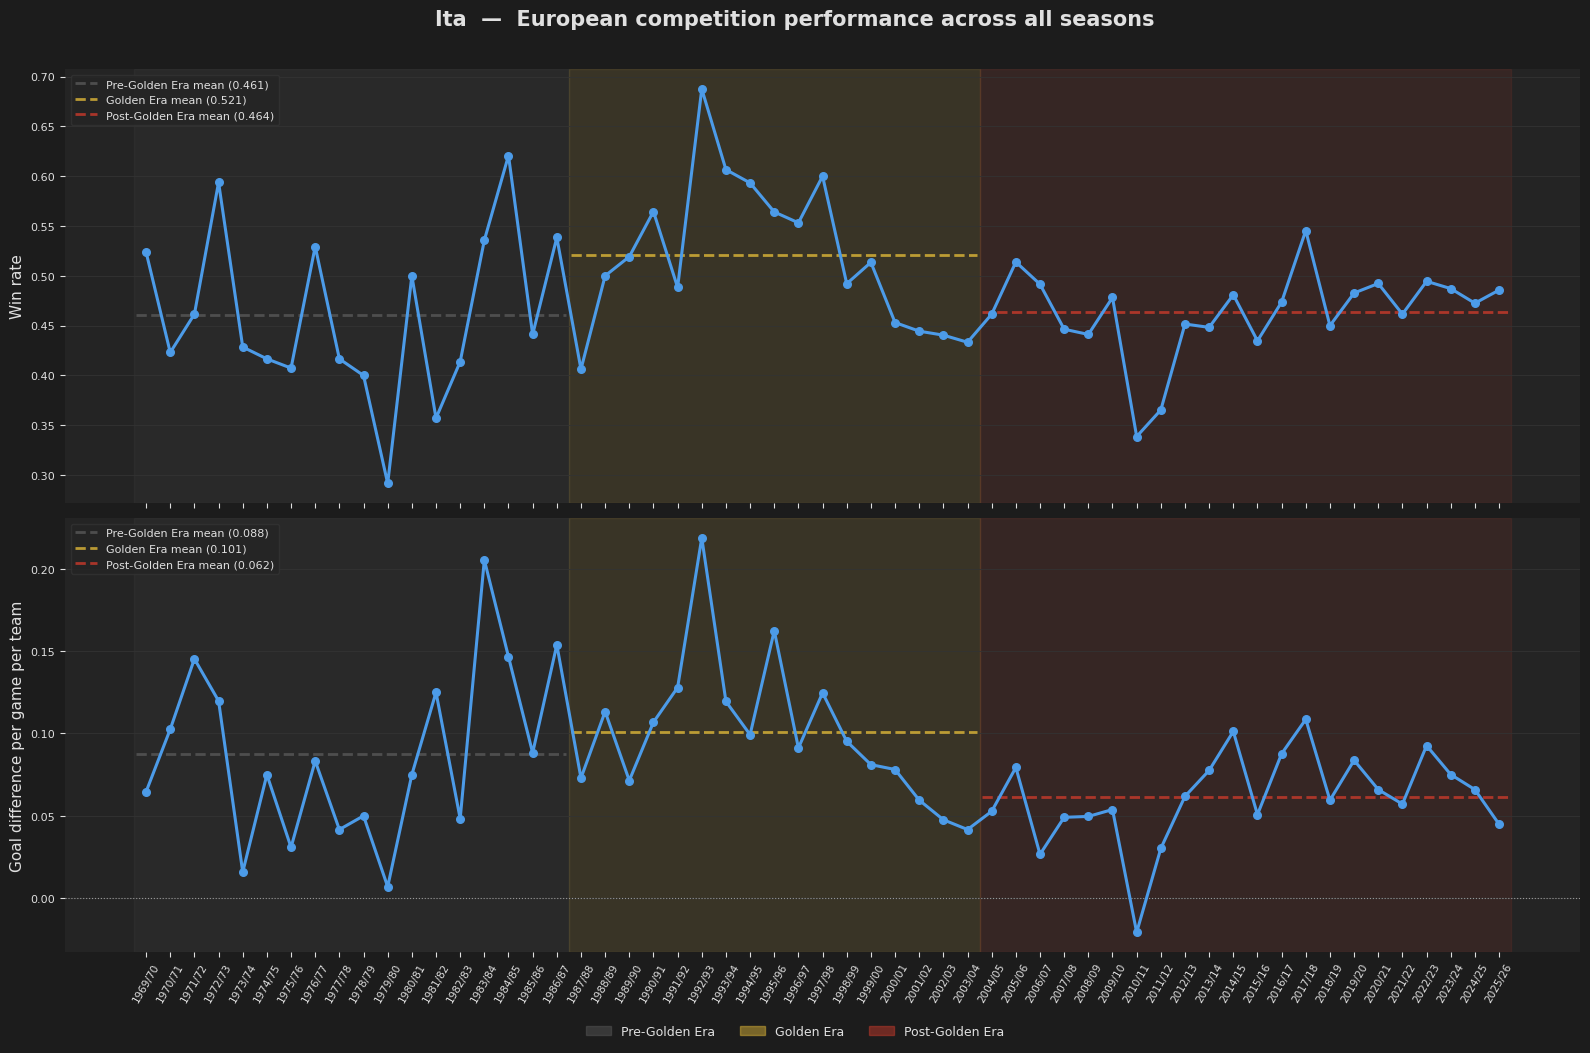

In [46]:
plot_italy_season_trend(italy_cs, charts_dir="../charts/", country_name="Ita")

## Plot 2: Box plot for comparing the distributions in the different eras

Box plots help us comparing Italy's `win_rate`, `ppg3_pt` and `gdpg_pt` distributions across the three eras — Pre, Golden, Post. Shows not just the mean but also how data are spread and outliers within each era.

In [47]:
# Box plots comparing Italy's metric distributions across eras
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Era labels 
ERA_PRE    = "Pre-Golden Era"
ERA_GOLDEN = "Golden Era"
ERA_POST   = "Post-Golden Era"

# Ordered list – useful for sorting / CategoricalDtype later
ERA_ORDER = [ERA_PRE, ERA_GOLDEN, ERA_POST]

# -- Palette ------------------------------------------------------------------
DARK_BG   = "#1C1C1C"
PANEL_BG  = "#242424"
GRID_COLOR = "#333333"
TEXT_COLOR = "#E0E0E0"
SUBTEXT    = "#999999"
MEDIAN_COLOR = "#FFFFFF"

ERA_COLORS = {
    "Pre-Golden Era" : "#7F8C8D",
    "Golden Era"     : "#D4AF37",
    "Post-Golden Era": "#C0392B",
}

METRICS = [
    ("win_rate", "Win rate"),
    ("ppg3_pt",  "PPG (3pt) per team"),
    ("gdpg_pt",  "Goal diff per game per team"),
]


def plot_era_boxplots(
    italy_cs:    pd.DataFrame,
    charts_dir:  str = "../charts/",
    country_name: str = "Ita",
    filename:    str = "4b_era_boxplots.png",
    dpi:         int = 150,
) -> None:
    """
    Plot metric distributions per era as box plots.

    Parameters
    ----------
    italy_cs     : Italy country_stats with 'era' and derived metric cols
    charts_dir   : output folder
    country_name : label used in title
    filename     : output filename
    dpi          : image resolution
    """
    for col, _ in METRICS:
        if col not in italy_cs.columns:
            raise KeyError(f"Column '{col}' missing. "
                           "Run add_derived_metrics() first.")

    fig, axes = plt.subplots(
        1, len(METRICS),
        figsize=(14, 6),
        facecolor=DARK_BG,
    )
    fig.suptitle(
        f"{country_name}  —  metric distributions by era",
        fontsize=14, fontweight="bold",
        color=TEXT_COLOR, y=1.02,
    )

    for ax, (col, label) in zip(axes, METRICS):
        ax.set_facecolor(PANEL_BG)

        data   = [italy_cs[italy_cs["era"] == era][col].dropna().values
                  for era in ERA_ORDER]
        colors = [ERA_COLORS[era] for era in ERA_ORDER]

        bp = ax.boxplot(
            data,
            patch_artist=True,
            notch=False,
            widths=0.5,
            medianprops=dict(color=MEDIAN_COLOR, linewidth=2),
            whiskerprops=dict(color=TEXT_COLOR, linewidth=1.2),
            capprops=dict(color=TEXT_COLOR, linewidth=1.2),
            flierprops=dict(marker="o", markersize=4,
                            markerfacecolor=SUBTEXT,
                            markeredgecolor="none"),
        )

        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.75)
            patch.set_edgecolor(TEXT_COLOR)
            patch.set_linewidth(1)

        # Era mean markers
        for i, era in enumerate(ERA_ORDER):
            vals = italy_cs[italy_cs["era"] == era][col].dropna()
            if vals.empty:
                continue
            ax.scatter(i + 1, vals.mean(),
                       marker="D", s=40,
                       color=MEDIAN_COLOR, zorder=5,
                       label="mean" if i == 0 else "")

        # Axis styling
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(["Pre", "Golden", "Post"],
                           color=TEXT_COLOR, fontsize=10)
        ax.set_title(label, color=TEXT_COLOR, fontsize=11, pad=8)
        ax.tick_params(colors=TEXT_COLOR)
        ax.spines[["top","right","left","bottom"]].set_visible(False)
        ax.grid(axis="y", color=GRID_COLOR, linewidth=0.6, zorder=0)

        # n label below each box
        for i, era in enumerate(ERA_ORDER):
            n = italy_cs[italy_cs["era"] == era][col].dropna().shape[0]
            ax.text(i + 1, ax.get_ylim()[0],
                    f"n={n}", ha="center", va="top",
                    color=SUBTEXT, fontsize=8)

    # Legend: era colours + mean marker
    era_patches = [mpatches.Patch(color=ERA_COLORS[e], alpha=0.75, label=e)
                   for e in ERA_ORDER]
    mean_marker = plt.Line2D([0], [0], marker="D", color="w",
                              markerfacecolor=MEDIAN_COLOR,
                              markersize=6, label="Era mean", linestyle="")
    fig.legend(handles=era_patches + [mean_marker],
               loc="lower center", ncol=4,
               fontsize=9, framealpha=0,
               labelcolor=TEXT_COLOR,
               bbox_to_anchor=(0.5, -0.04))

    plt.tight_layout()
    _save(fig, charts_dir, filename, dpi)
    plt.show()


# -- Helper -------------------------------------------------------------------

def _save(fig, charts_dir: str, filename: str, dpi: int) -> None:
    import os
    os.makedirs(charts_dir, exist_ok=True)
    path = os.path.join(charts_dir, filename)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=DARK_BG)
    print(f"  Saved -> {path}")

  Saved -> ../charts/4b_era_boxplots.png


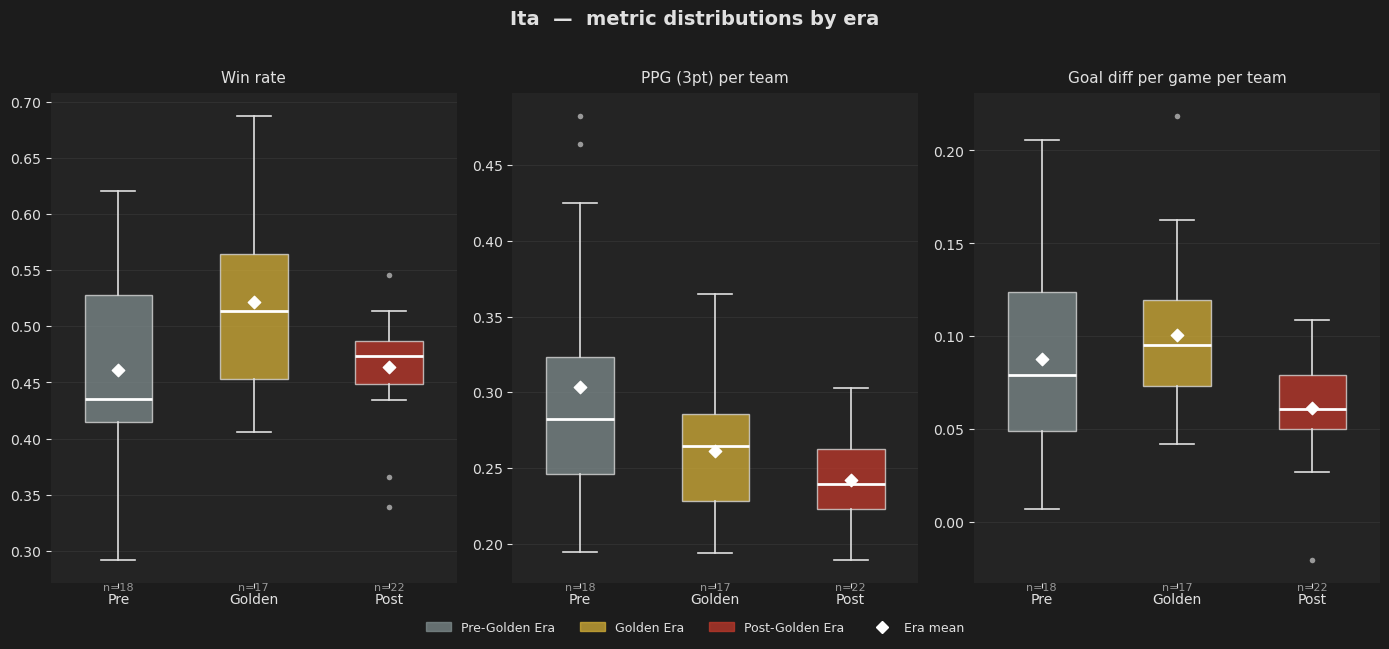

In [48]:
plot_era_boxplots(italy_cs, charts_dir="../charts/", country_name="Ita")

Something interesting to note. 
1. PPG per team, again, just show a consistency in the points gained as the number of teams increased during the years. Notable that Golden and post era per PPG per team is lower while the number of teams is more or less the same.
2. The win rate int the post contains few outliers: this is an indication of less consistency in results. It looks that Italian clubs or enjoyed years with very good or very bad performances, while the Golden era mean and median are very similar, meaning that results were consistent. 

## Plot 3: Bubble chart of all countries during the Golden Era

Bubble chart of all countries during the Golden Era. Each bubble is one country positioned at `avg_win_rate` ($x$) x `avg_round_ord` ($y$), with bubble size proportional to `avg_num_teams`. Italy highlighted in azzurri blue, top countries labelled.

In [67]:
"""
Step 4c - Country bubble chart
--------------------------------
Scatter / bubble chart of all Golden Era countries.

  x-axis  : avg_win_rate
  y-axis  : avg_round_ord  (tournament depth)
  size    : avg_num_teams  (entry quota)
  colour  : focal country highlighted, rest in muted tone
  labels  : top_n countries by composite_score

Input
-----
  rankings : DataFrame from step2e build_composite()
             one row per country, Golden Era aggregates

Output
------
  PNG saved to charts_dir / '4c_country_bubble.png'
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# -- Palette ------------------------------------------------------------------
DARK_BG      = "#1C1C1C"
PANEL_BG     = "#242424"
GRID_COLOR   = "#333333"
TEXT_COLOR   = "#E0E0E0"
SUBTEXT      = "#888888"
FOCAL_COLOR  = "#4C9BE8"   # azzurri blue
OTHER_COLOR  = "#4A4A4A"
TOP_N_BORDER = "#D4AF37"   # gold border for top-n bubbles
LABEL_COLOR  = "#CCCCCC"


def plot_country_bubble(
    rankings:     pd.DataFrame,
    charts_dir:   str  = "../charts/",
    country_name: str  = "Ita",
    country_col:  str  = "country",
    top_n:        int  = 10,
    filename:     str  = "4c_country_bubble.png",
    dpi:          int  = 150,
) -> None:
    """
    Bubble chart: win rate x avg round depth, sized by avg num teams.

    Parameters
    ----------
    rankings     : step2e build_composite() output
    charts_dir   : output folder
    country_name : focal country to highlight
    country_col  : country column name
    top_n        : how many countries to label
    filename     : output filename
    dpi          : image resolution
    """
    needed = ["avg_win_rate", "avg_round_ord",
              "avg_num_teams", "composite_score", country_col]
    missing = [c for c in needed if c not in rankings.columns]
    if missing:
        raise KeyError(f"Missing columns in rankings: {missing}")

    df      = rankings.dropna(subset=["avg_win_rate","avg_round_ord"]).copy()
    name_up = country_name.strip().upper()

    # Bubble size: scale avg_num_teams to a readable range
    max_teams = df["avg_num_teams"].max()
    df["_size"] = ((df["avg_num_teams"] / max_teams) * 800).clip(lower=60)

    # Top-n countries to label (by composite score)
    label_set = set(
        df.nlargest(top_n, "composite_score")[country_col].tolist()
    )
    # Always label focal country
    label_set.add(
        df[df[country_col].str.upper() == name_up][country_col].values[0]
        if not df[df[country_col].str.upper() == name_up].empty
        else country_name
    )

    fig, ax = plt.subplots(figsize=(13, 8), facecolor=DARK_BG)
    ax.set_facecolor(PANEL_BG)

    top_n_set = set(
        df.nlargest(top_n, "composite_score")[country_col].tolist()
    )

    # -- Layer 1: non-focal, non-top-n (background) ---------------------------
    rest = df[
        (df[country_col].str.upper() != name_up) &
        (~df[country_col].isin(top_n_set))
    ]
    ax.scatter(rest["avg_win_rate"], rest["avg_round_ord"],
               s=rest["_size"], color=OTHER_COLOR,
               alpha=0.45, edgecolors="#555555", linewidths=0.5,
               zorder=2)

    # -- Layer 2: top-n countries (coloured border) ---------------------------
    top_rest = df[
        (df[country_col].str.upper() != name_up) &
        (df[country_col].isin(top_n_set))
    ]
    ax.scatter(top_rest["avg_win_rate"], top_rest["avg_round_ord"],
               s=top_rest["_size"], color=OTHER_COLOR,
               alpha=0.65, edgecolors=TOP_N_BORDER, linewidths=1.8,
               zorder=3)

    # -- Layer 3: focal country on top ----------------------------------------
    focal = df[df[country_col].str.upper() == name_up]
    if not focal.empty:
        ax.scatter(focal["avg_win_rate"], focal["avg_round_ord"],
                   s=focal["_size"] * 1.4,
                   color=FOCAL_COLOR, alpha=0.95,
                   edgecolors="white", linewidths=1.2,
                   zorder=4)

    # -- Labels ---------------------------------------------------------------
    for _, r in df.iterrows():
        if r[country_col] not in label_set:
            continue
        is_focal = r[country_col].upper() == name_up
        if is_focal:
            # color = "#FFFFFF"           # white on blue bubble #A12300
            color = "#CE7F00"
        elif r[country_col] in top_n_set:
            color = TOP_N_BORDER        # gold matching border
        else:
            color = LABEL_COLOR
        weight   = "bold" if is_focal else "normal"
        fontsize = 10 if is_focal else 8

        ax.annotate(
            r[country_col],
            xy=(r["avg_win_rate"], r["avg_round_ord"]),
            xytext=(6, 4), textcoords="offset points",
            fontsize=fontsize, color=color,
            fontweight=weight, zorder=5,
        )

    # -- Reference lines (field medians) -------------------------------------
    med_x = df["avg_win_rate"].median()
    med_y = df["avg_round_ord"].median()
    ax.axvline(med_x, color=SUBTEXT, linewidth=0.8,
               linestyle="--", alpha=0.6, zorder=1)
    ax.axhline(med_y, color=SUBTEXT, linewidth=0.8,
               linestyle="--", alpha=0.6, zorder=1)
    ax.text(med_x + 0.002, ax.get_ylim()[0] + 0.05,
            "field median", color=SUBTEXT, fontsize=7.5)

    # -- Round depth y-axis tick labels ---------------------------------------
    ROUND_GROUPS = ["stage", "Round of 16", "Quarter Finals", "Semi Finals", "Final"]
    
    ax.set_yticks(range(len(ROUND_GROUPS)))
    ax.set_yticklabels(ROUND_GROUPS, color=TEXT_COLOR, fontsize=9)

    # -- Axes styling ---------------------------------------------------------
    ax.set_xlabel("Average win rate", color=TEXT_COLOR, fontsize=11)
    ax.set_ylabel("Average deepest round", color=TEXT_COLOR, fontsize=11)
    ax.set_title(
        f"Country performance — Golden Era  "
        f"(bubble size ∝ avg teams entered,  top {top_n} labelled)",
        color=TEXT_COLOR, fontsize=12, fontweight="bold", pad=12,
    )
    ax.tick_params(colors=TEXT_COLOR)
    ax.spines[["top","right","left","bottom"]].set_visible(False)
    ax.grid(color=GRID_COLOR, linewidth=0.5, zorder=0)

    # -- Bubble size legend ---------------------------------------------------
    size_vals  = [1, 3, 5]
    size_labels = [f"{int(v)} teams" for v in size_vals]
    legend_handles = [
        mlines.Line2D([], [], marker="o", linestyle="",
                      markersize=np.sqrt((v / max_teams) * 800).clip(4),
                      color=OTHER_COLOR, alpha=0.7, label=lbl)
        for v, lbl in zip(size_vals, size_labels)
    ]
    focal_handle = mlines.Line2D(
        [], [], marker="o", linestyle="",
        markersize=10, color=FOCAL_COLOR,
        label=country_name,
    )
    ax.legend(
        handles=legend_handles + [focal_handle],
        loc="lower right", fontsize=8,
        facecolor=PANEL_BG, edgecolor=GRID_COLOR,
        labelcolor=TEXT_COLOR, framealpha=0.8,
    )

    plt.tight_layout()
    _save(fig, charts_dir, filename, dpi)
    plt.show()


# -- Helper -------------------------------------------------------------------

def _save(fig, charts_dir: str, filename: str, dpi: int) -> None:
    import os
    os.makedirs(charts_dir, exist_ok=True)
    path = os.path.join(charts_dir, filename)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=DARK_BG)
    print(f"  Saved -> {path}")

  Saved -> ../charts/4c_country_bubble.png


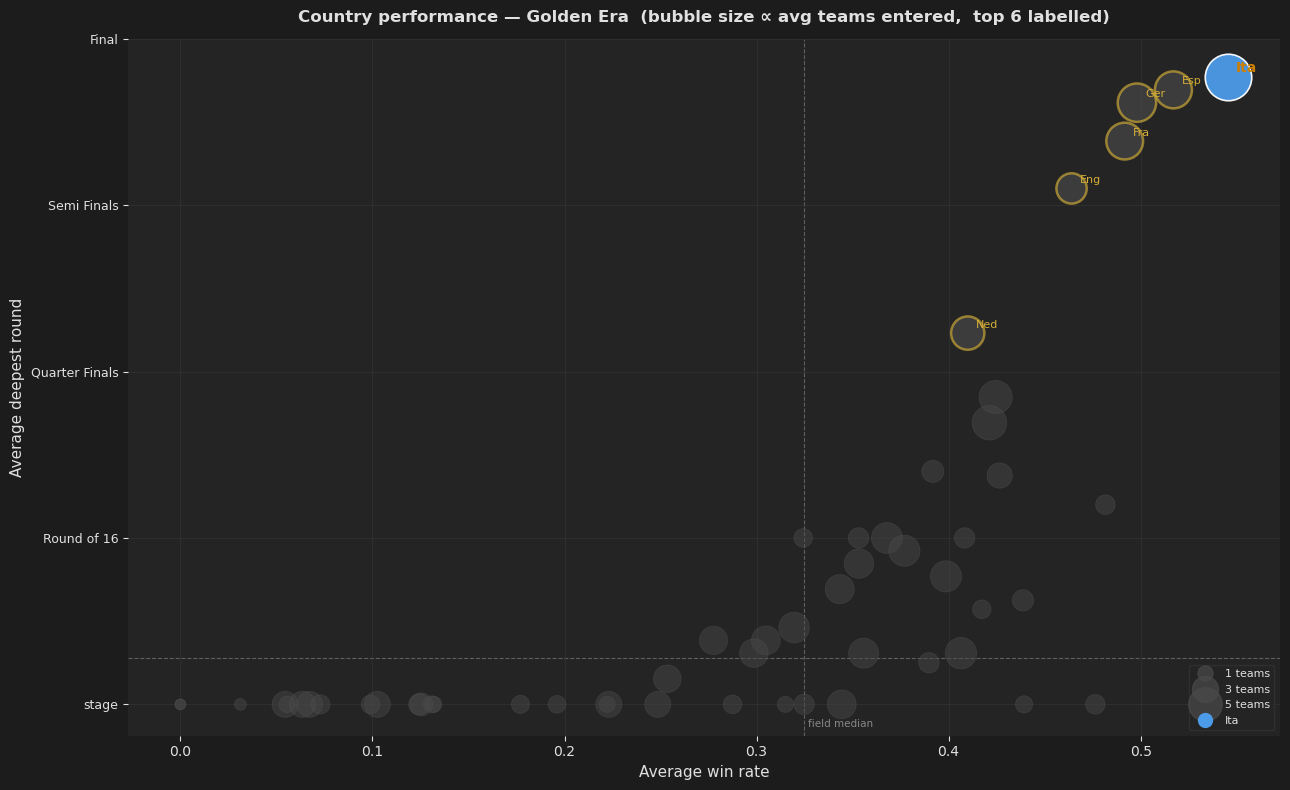

In [68]:
plot_country_bubble(rankings, charts_dir="../charts/",
                    country_name="Ita", top_n=6)

## Plot 4: Top *N* countries by *composite score*

Horizontal bar chart of the top N countries by composite score. Italy highlighted, bars colour-coded, score value annotated at the end of each bar.

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -- Palette ------------------------------------------------------------------
DARK_BG      = "#1C1C1C"
PANEL_BG     = "#242424"
GRID_COLOR   = "#333333"
TEXT_COLOR   = "#E0E0E0"
SUBTEXT      = "#888888"
FOCAL_COLOR  = "#4C9BE8"   # Italy (blue)
GOLD_COLOR   = "#D4AF37"   # top-n
MUTED_COLOR  = "#4A4A4A"   # rest


def plot_composite_bar(
    rankings:     pd.DataFrame,
    charts_dir:   str = "../charts/",
    country_name: str = "Ita",
    country_col:  str = "country",
    top_n:        int = 15,
    filename:     str = "4d_composite_bar.png",
    dpi:          int = 150,
) -> None:
    """
    Horizontal bar chart of top-N countries by composite score.

    Parameters
    ----------
    rankings     : step2e output, one row per country
    charts_dir   : output folder
    country_name : focal country to highlight
    country_col  : country column name
    top_n        : number of countries to show
    filename     : output filename
    dpi          : image resolution
    """
    needed = ["composite_score", "avg_win_rate",
              "avg_round_ord", country_col]
    missing = [c for c in needed if c not in rankings.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    name_up = country_name.strip().upper()

    # Top-N by composite score, sorted ascending for horizontal bars
    df = (rankings.dropna(subset=["composite_score"])
                  .nlargest(top_n, "composite_score")
                  .sort_values("composite_score", ascending=True)
                  .reset_index(drop=True))

    # Bar colours
    colors = []
    for c in df[country_col]:
        if c.upper() == name_up:
            colors.append(FOCAL_COLOR)
        elif c in df.nlargest(5, "composite_score")[country_col].values:
            colors.append(GOLD_COLOR)
        else:
            colors.append(MUTED_COLOR)

    fig, ax = plt.subplots(
        figsize=(12, max(6, top_n * 0.52)),
        facecolor=DARK_BG,
    )
    ax.set_facecolor(PANEL_BG)

    y = np.arange(len(df))
    bars = ax.barh(y, df["composite_score"],
                   color=colors, height=0.65,
                   edgecolor="none", zorder=2)

    # -- Score label at end of bar -------------------------------------------
    for i, (bar, row) in enumerate(zip(bars, df.itertuples())):
        score = row.composite_score
        # Score value
        ax.text(score + 0.005, i,
                f"{score:.3f}",
                va="center", ha="left",
                color=TEXT_COLOR, fontsize=8.5, zorder=3)
        # Secondary stats (win rate + avg round)
        ax.text(score + 0.005, i - 0.28,
                f"wr {row.avg_win_rate:.2f}  "
                f"rnd {row.avg_round_ord:.2f}",
                va="center", ha="left",
                color=SUBTEXT, fontsize=7, zorder=3)

    # -- Y-axis: country labels -----------------------------------------------
    ax.set_yticks(y)
    ax.set_yticklabels(df[country_col], color=TEXT_COLOR, fontsize=9)

    # Highlight focal country label
    for label, c in zip(ax.get_yticklabels(), df[country_col]):
        if c.upper() == name_up:
            label.set_color(FOCAL_COLOR)
            label.set_fontweight("bold")

    # -- Axis styling ---------------------------------------------------------
    ax.set_xlabel("Composite dominance score", color=TEXT_COLOR, fontsize=10)
    ax.set_title(
        f"Top {top_n} countries — composite dominance score  (Golden Era)\n"
        f"Weights: depth 35%  ·  win rate 25%  ·  PPG/team 25%  ·  GDpG 15%",
        color=TEXT_COLOR, fontsize=11, fontweight="bold", pad=10,
    )
    ax.tick_params(colors=TEXT_COLOR)
    ax.spines[["top","right","left","bottom"]].set_visible(False)
    ax.grid(axis="x", color=GRID_COLOR, linewidth=0.5, zorder=0)

    # Extend x-axis to leave room for annotations
    xmax = df["composite_score"].max()
    ax.set_xlim(0, xmax * 1.35)

    # -- Legend ---------------------------------------------------------------
    from matplotlib.patches import Patch
    legend_handles = [
        Patch(color=FOCAL_COLOR, label=country_name),
        Patch(color=GOLD_COLOR,  label="Top 5"),
        Patch(color=MUTED_COLOR, label="Other"),
    ]
    ax.legend(handles=legend_handles,
              loc="lower right", fontsize=8,
              facecolor=PANEL_BG, edgecolor=GRID_COLOR,
              labelcolor=TEXT_COLOR, framealpha=0.8)

    plt.tight_layout()
    _save(fig, charts_dir, filename, dpi)
    plt.show()


# -- Helper -------------------------------------------------------------------

def _save(fig, charts_dir: str, filename: str, dpi: int) -> None:
    import os
    os.makedirs(charts_dir, exist_ok=True)
    path = os.path.join(charts_dir, filename)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=DARK_BG)
    print(f"  Saved -> {path}")

  Saved -> ../charts/4d_composite_bar.png


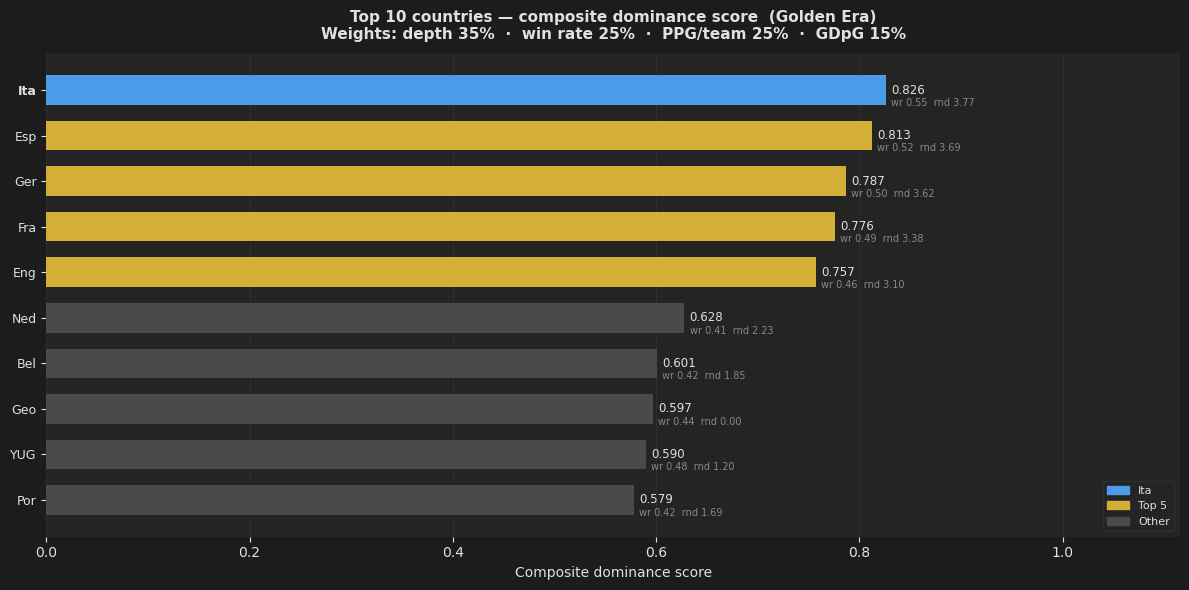

In [70]:
plot_composite_bar(rankings, charts_dir="../charts/",
                   country_name="Ita", top_n=10)

## Plot 5: Season-by-season rank of the top countries (Golden Era)

Bump chart showing season-by-season rank of the top countries during the Golden Era. Each country is a line, rank on y-axis (inverted, 1 = top), seasons on $x$-axis. Italy highlighted in blue, rivals in muted colours.

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# -- Palette ------------------------------------------------------------------
DARK_BG     = "#1C1C1C"
PANEL_BG    = "#242424"
GRID_COLOR  = "#333333"
TEXT_COLOR  = "#E0E0E0"
SUBTEXT     = "#666666"
FOCAL_COLOR = "#4C9BE8"

# Distinct colours for top rivals
RIVAL_COLORS = [
    "#D4AF37", "#E8734C", "#7EC8A4", "#C47FD5",
    "#E8C44C", "#4CD5E8", "#E84C7F", "#A4C84C",
]


def plot_bump_chart(
    ge_cs:        pd.DataFrame,
    charts_dir:   str       = "../charts/",
    country_name: str       = "Ita",
    country_col:  str       = "country",
    top_n:        int       = 8,
    filename:     str       = "4e_bump_chart.png",
    dpi:          int       = 150,
) -> None:
    """
    Bump chart of season-by-season country rankings (by win rate).

    Parameters
    ----------
    ge_cs        : Golden Era country_stats, one row per country x season
    charts_dir   : output folder
    country_name : focal country to highlight
    country_col  : country column name
    top_n        : number of countries to plot (focal + top n-1 rivals)
    filename     : output filename
    dpi          : image resolution
    """
    needed = ["season", "win_rate", country_col]
    missing = [c for c in needed if c not in ge_cs.columns]
    if missing:
        raise KeyError(f"Missing columns in ge_cs: {missing}")

    name_up = country_name.strip().upper()

    # -- Compute per-season ranks -------------------------------------------
    seasons = sorted(ge_cs["season"].unique(),
                     key=lambda s: int(str(s).split("/")[0]))

    rank_records = []
    for s in seasons:
        sub = ge_cs[ge_cs["season"] == s].copy()
        sub["_rank"] = sub["win_rate"].rank(ascending=False,
                                             method="min",
                                             na_option="bottom").astype("Int64")
        for _, r in sub.iterrows():
            rank_records.append({
                country_col: r[country_col],
                "season":    s,
                # convert Int64 to plain Python int; NaN stays as np.nan
                "rank":      (int(r["_rank"])
                              if pd.notna(r["_rank"]) else np.nan),
                "win_rate":  r["win_rate"],
            })

    rank_df = pd.DataFrame(rank_records)

    # -- Select countries to plot -------------------------------------------
    # Mean rank across all seasons (lower = better)
    mean_ranks = (rank_df.groupby(country_col)["rank"]
                         .mean()
                         .sort_values())

    # Always include focal country
    focal_in_data = name_up in rank_df[country_col].str.upper().values

    top_countries = mean_ranks.head(top_n).index.tolist()
    focal_key     = next(
        (c for c in rank_df[country_col].unique() if c.upper() == name_up),
        None
    )
    if focal_key and focal_key not in top_countries:
        top_countries = top_countries[:top_n - 1] + [focal_key]

    # Assign colours
    rival_list = [c for c in top_countries if c.upper() != name_up]
    color_map  = {c: RIVAL_COLORS[i % len(RIVAL_COLORS)]
                  for i, c in enumerate(rival_list)}
    if focal_key:
        color_map[focal_key] = FOCAL_COLOR

    # -- Figure ---------------------------------------------------------------
    n_seasons = len(seasons)
    fig, ax   = plt.subplots(
        figsize=(max(14, n_seasons * 0.9), 8),
        facecolor=DARK_BG,
    )
    ax.set_facecolor(PANEL_BG)

    # Max rank shown (for y-axis)
    max_rank = rank_df[rank_df[country_col].isin(top_countries)]["rank"].max()
    max_rank = max(max_rank, top_n)

    for country in top_countries:
        is_focal  = country.upper() == name_up
        color     = color_map.get(country, SUBTEXT)
        lw        = 3.0 if is_focal else 1.6
        alpha     = 1.0 if is_focal else 0.75
        zorder    = 5 if is_focal else 3
        ms        = 7  if is_focal else 4

        sub = (rank_df[rank_df[country_col] == country]
               .set_index("season")
               .reindex(seasons))
        ranks = sub["rank"].values

        x_vals = np.arange(n_seasons)
        ax.plot(x_vals, ranks,
                color=color, linewidth=lw,
                alpha=alpha, zorder=zorder,
                marker="o", markersize=ms,
                markerfacecolor=color,
                markeredgecolor=DARK_BG,
                markeredgewidth=0.8)

        # Label at right end
        last_valid = next(
            (i for i in range(n_seasons - 1, -1, -1)
             if not np.isnan(ranks[i])),
            None
        )
        if last_valid is not None:
            ax.text(
                last_valid + 0.25,
                ranks[last_valid],
                f" {country}",
                va="center", fontsize=9 if is_focal else 7.5,
                color=color, fontweight="bold" if is_focal else "normal",
                zorder=6,
                path_effects=[
                    pe.withStroke(linewidth=2, foreground=PANEL_BG)
                ],
            )

    # -- Axes styling ---------------------------------------------------------
    ax.set_xlim(-0.5, n_seasons - 0.5 + 2)   # room for labels
    ax.set_ylim(max_rank + 0.8, 0.2)           # inverted, rank 1 at top
    ax.set_xticks(np.arange(n_seasons))
    ax.set_xticklabels(seasons, rotation=55,
                       fontsize=8, color=TEXT_COLOR)
    ax.set_ylabel("Rank (by win rate)", color=TEXT_COLOR, fontsize=10)
    ax.set_yticks(range(1, max_rank + 1))
    ax.set_yticklabels(range(1, max_rank + 1),
                       color=TEXT_COLOR, fontsize=8)
    ax.set_title(
        f"Season-by-season country rankings — Golden Era\n"
        f"(rank by win rate per season  ·  lower = better  ·  "
        f"top {top_n} shown)",
        color=TEXT_COLOR, fontsize=11,
        fontweight="bold", pad=10,
    )
    ax.tick_params(colors=TEXT_COLOR)
    ax.spines[["top","right","left","bottom"]].set_visible(False)
    ax.grid(axis="y", color=GRID_COLOR,
            linewidth=0.4, linestyle="--", zorder=0)

    # Highlight rank-1 band
    ax.axhspan(0.5, 1.5, color=FOCAL_COLOR, alpha=0.06, zorder=0)

    plt.tight_layout()
    _save(fig, charts_dir, filename, dpi)
    plt.show()


# -- Helper -------------------------------------------------------------------

def _save(fig, charts_dir: str, filename: str, dpi: int) -> None:
    import os
    os.makedirs(charts_dir, exist_ok=True)
    path = os.path.join(charts_dir, filename)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=DARK_BG)
    print(f"  Saved -> {path}")

  Saved -> ../charts/4e_bump_chart.png


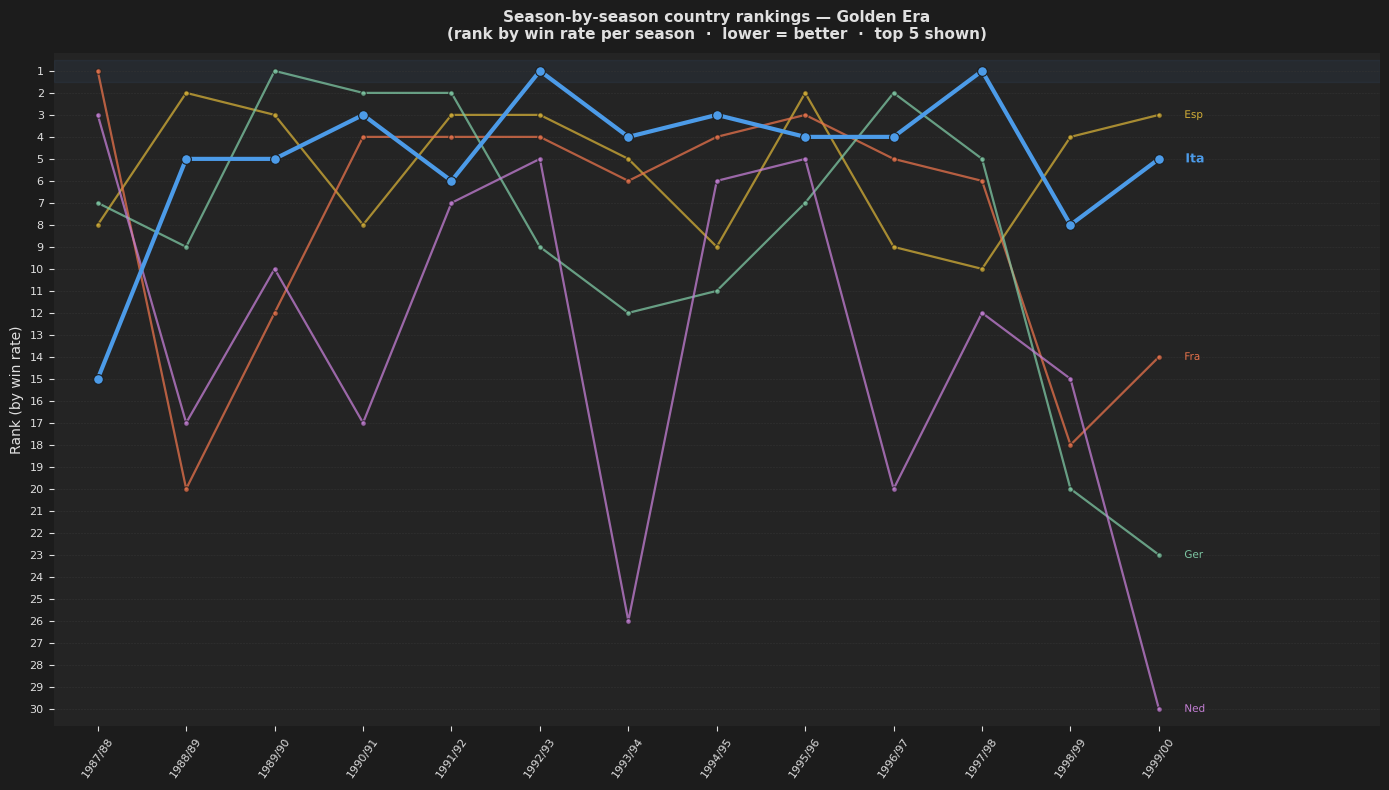

In [85]:
plot_bump_chart(ge["cs"], charts_dir="../charts/",
                country_name="Ita", top_n=5)

- $y$-axis is inverted so rank 1 sits at the top, which reads naturally. 


## Plot 6: Average round depth 

Heatmap of *average round depth*. `countries` on the $y$-axis, competitions (CL, CW, EL) on the $x$-axis, cell colour represents `avg_round_ord`. Italy's row highlighted with a borde.

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

# -- Palette ------------------------------------------------------------------
DARK_BG      = "#1C1C1C"
PANEL_BG     = "#242424"
TEXT_COLOR   = "#E0E0E0"
SUBTEXT      = "#888888"
FOCAL_COLOR  = "#4C9BE8"
GRID_COLOR   = "#333333"

# Heatmap colour ramp: dark panel -> gold -> white
CMAP = LinearSegmentedColormap.from_list(
    "depth",
    ["#2A2A2A", "#5B4A1A", "#D4AF37", "#F5E6A3", "#FFFFFF"],
)


def plot_competition_heatmap(
    pivot:        pd.DataFrame,
    charts_dir:   str  = "../charts/",
    country_name: str  = "Ita",
    top_n:        int  = 20,
    filename:     str  = "4f_competition_heatmap.png",
    dpi:          int  = 150,
) -> None:
    """
    Heatmap of avg round depth per country x competition.

    Parameters
    ----------
    pivot        : step2d pivot output (country x competition)
    charts_dir   : output folder
    country_name : focal country to highlight
    top_n        : max countries to display (by row mean, focal always included)
    filename     : output filename
    dpi          : image resolution
    """
    if pivot.empty:
        print("  pivot is empty — nothing to plot.")
        return

    name_up = country_name.strip().upper()

    # -- Select top_n countries by row mean, always include focal -------------
    row_means = pivot.mean(axis=1).sort_values(ascending=False)
    top_countries = row_means.head(top_n).index.tolist()
    focal_key = next(
        (c for c in pivot.index if c.upper() == name_up), None
    )
    if focal_key and focal_key not in top_countries:
        top_countries = top_countries[:top_n - 1] + [focal_key]

    df = pivot.loc[top_countries].copy()

    # Sort by row mean descending (focal will float naturally)
    df = df.loc[df.mean(axis=1).sort_values(ascending=False).index]

    n_rows, n_cols = df.shape
    fig_h = max(6, n_rows * 0.52)

    fig, ax = plt.subplots(figsize=(max(6, n_cols * 2.2), fig_h),
                           facecolor=DARK_BG)
    ax.set_facecolor(PANEL_BG)

    vmin = 0
    vmax = 4   # ordinal scale: stage=0 … Final=4

    im = ax.imshow(df.values.astype(float),
                   cmap=CMAP, aspect="auto",
                   vmin=vmin, vmax=vmax)

    # -- Cell annotations -----------------------------------------------------
    
    ROUND_GROUPS = ["stage", "Round of 16", "Quarter Finals", "Semi Finals", "Final"]
    
    for i in range(n_rows):
        for j in range(n_cols):
            val = df.iloc[i, j]
            if pd.isna(val):
                ax.text(j, i, "—", ha="center", va="center",
                        fontsize=9, color=SUBTEXT)
            else:
                # Text colour: dark on light cells, light on dark cells
                txt_color = "#1C1C1C" if val > 2.5 else TEXT_COLOR
                # Round label below the number
                label = ROUND_GROUPS[round(val)] if 0 <= round(val) <= 4 else ""
                ax.text(j, i - 0.15,
                        f"{val:.2f}",
                        ha="center", va="center",
                        fontsize=9.5, fontweight="bold",
                        color=txt_color)
                ax.text(j, i + 0.25,
                        label,
                        ha="center", va="center",
                        fontsize=7, color=txt_color, alpha=0.8)

    # -- Focal row highlight --------------------------------------------------
    focal_idx = df.index.tolist().index(focal_key) if focal_key in df.index else None
    if focal_idx is not None:
        rect = mpatches.FancyBboxPatch(
            (-0.5, focal_idx - 0.5),
            n_cols, 1,
            boxstyle="square,pad=0",
            linewidth=2.5,
            edgecolor=FOCAL_COLOR,
            facecolor="none",
            zorder=4,
        )
        ax.add_patch(rect)

    # -- Axes -----------------------------------------------------------------
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(df.columns.tolist(),
                       color=TEXT_COLOR, fontsize=11, fontweight="bold")
    ax.set_yticks(range(n_rows))
    yticklabels = ax.set_yticklabels(df.index.tolist(),
                                      color=TEXT_COLOR, fontsize=9)

    # Highlight focal country y-label
    for label, country in zip(yticklabels, df.index.tolist()):
        if country.upper() == name_up:
            label.set_color(FOCAL_COLOR)
            label.set_fontweight("bold")

    ax.set_title(
        f"Avg deepest round by country & competition — Golden Era\n"
        f"(0 = stage  ·  1 = R16  ·  2 = QF  ·  3 = SF  ·  4 = Final)",
        color=TEXT_COLOR, fontsize=11,
        fontweight="bold", pad=12,
    )
    ax.tick_params(colors=TEXT_COLOR, length=0)
    ax.spines[["top","right","left","bottom"]].set_visible(False)

    # -- Colourbar ------------------------------------------------------------
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.ax.tick_params(colors=TEXT_COLOR, labelsize=8)
    cbar.outline.set_edgecolor(GRID_COLOR)
    cbar.set_label("Avg round (ordinal)", color=TEXT_COLOR, fontsize=9)

    plt.tight_layout()
    _save(fig, charts_dir, filename, dpi)
    plt.show()


# -- Helper -------------------------------------------------------------------

def _save(fig, charts_dir: str, filename: str, dpi: int) -> None:
    import os
    os.makedirs(charts_dir, exist_ok=True)
    path = os.path.join(charts_dir, filename)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=DARK_BG)
    print(f"  Saved -> {path}")

  [comp] WARNING - 884 row(s) have unrecognised highest_round values -> treated as NaN:
    'not partecipate'  (884 row(s))

  Per-competition breakdown (Golden Era)

  [CL]  Italy: rank #1 of 59 | avg round ord 3.31
    #  Country                  N   Avg round   Finals   Semis
  -------------------------------------------------------
    1  Ita                     13       3.308        9       1
    2  Esp                     13       2.462        4       2
    3  Fra                     13       2.231        2       5
    3  Ger                     13       2.231        2       5
    5  Ned                     13       1.583        3       1
    6  Por                     13       1.462        2       1
    7  Eng                     13       1.222        1       1
    8  URS                     13       1.000        0       1

  [CW]  Italy: rank #1 of 59 | avg round ord 3.25
    #  Country                  N   Avg round   Finals   Semis
  ------------------------------------------

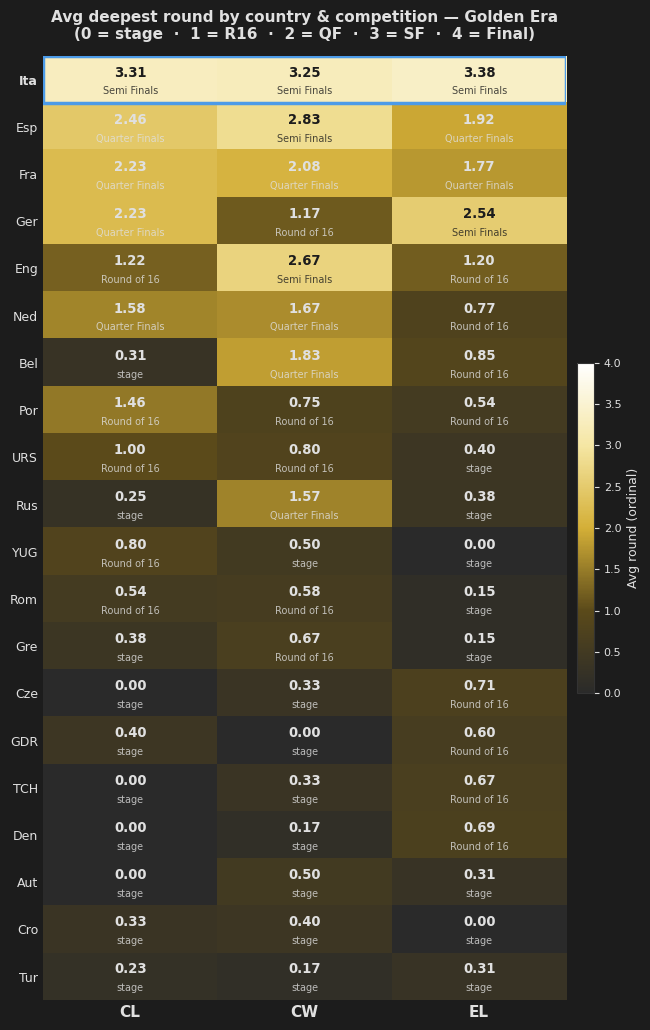

In [89]:
# Filter pivot to valid competitions first
valid_comps     = ["CL", "CW", "EL"]
ge_csch_filtered = ge["csch"][ge["csch"]["competition"].isin(valid_comps)]
_, pivot        = country_competition_breakdown(ge_csch_filtered)

plot_competition_heatmap(pivot, charts_dir="../charts/",
                         country_name="Ita", top_n=20)

## Plot 7: Top countries comparison across all normalised metric.

Radar chart comparing the top countries across all normalised metric pillars — `avg_win_rate`, `avg_ppg3_pt`, `avg_gdpg_pt`, `avg_round_ord`. Each country is one polygon. Italy filled and highlighted, rivals as outlines only.

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# -- Palette ------------------------------------------------------------------
DARK_BG     = "#1C1C1C"
PANEL_BG    = "#242424"
GRID_COLOR  = "#3A3A3A"
TEXT_COLOR  = "#E0E0E0"
FOCAL_COLOR = "#4C9BE8"
FOCAL_FILL  = "#4C9BE8"

RIVAL_COLORS = [
    "#D4AF37", "#E8734C", "#7EC8A4", "#C47FD5",
    "#E8C44C", "#4CD5E8", "#E84C7F", "#A4C84C",
]

# Norm columns and their display labels
PILLARS = [
    ("avg_win_rate_norm",  "Win rate"),
    ("avg_ppg3_pt_norm",   "PPG / team"),
    ("avg_gdpg_pt_norm",   "GDpG / team"),
    ("avg_round_ord_norm", "Round depth"),
]


def plot_radar(
    rankings:     pd.DataFrame,
    charts_dir:   str  = "../charts/",
    country_name: str  = "Ita",
    country_col:  str  = "country",
    top_n:        int  = 6,
    filename:     str  = "4g_radar.png",
    dpi:          int  = 150,
) -> None:
    """
    Radar chart of normalised metric pillars for top-N countries.

    Parameters
    ----------
    rankings     : step2e output with *_norm columns
    charts_dir   : output folder
    country_name : focal country to highlight
    country_col  : country column name
    top_n        : total countries to plot (focal + top n-1)
    filename     : output filename
    dpi          : image resolution
    """
    # -- Validate norm columns ------------------------------------------------
    norm_cols = [c for c, _ in PILLARS]
    missing   = [c for c in norm_cols if c not in rankings.columns]
    if missing:
        raise KeyError(
            f"Missing normalised columns: {missing}\n"
            "These are produced by build_composite() in step2e. "
            "Make sure you are passing the rankings DataFrame directly."
        )

    name_up = country_name.strip().upper()

    # -- Select countries to plot ---------------------------------------------
    df = rankings.dropna(subset=norm_cols).copy()

    top_countries = df.nlargest(top_n, "composite_score")[country_col].tolist()
    focal_key     = next(
        (c for c in df[country_col] if c.upper() == name_up), None
    )
    if focal_key and focal_key not in top_countries:
        top_countries = top_countries[:top_n - 1] + [focal_key]

    rival_list = [c for c in top_countries if c.upper() != name_up]
    color_map  = {c: RIVAL_COLORS[i % len(RIVAL_COLORS)]
                  for i, c in enumerate(rival_list)}
    if focal_key:
        color_map[focal_key] = FOCAL_COLOR

    # -- Radar geometry -------------------------------------------------------
    n_pillars = len(PILLARS)
    angles    = np.linspace(0, 2 * np.pi, n_pillars,
                            endpoint=False).tolist()
    angles   += angles[:1]   # close the polygon

    labels = [lbl for _, lbl in PILLARS]

    # -- Figure ---------------------------------------------------------------
    fig, ax = plt.subplots(
        figsize=(9, 9),
        subplot_kw=dict(polar=True),
        facecolor=DARK_BG,
    )
    ax.set_facecolor(PANEL_BG)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # Grid rings
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"],
                       color=GRID_COLOR, fontsize=7)
    ax.yaxis.grid(color=GRID_COLOR, linewidth=0.6, linestyle="--")
    ax.xaxis.grid(color=GRID_COLOR, linewidth=0.6)
    ax.spines["polar"].set_color(GRID_COLOR)

    # Axis labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, color=TEXT_COLOR, fontsize=11)

    # -- Plot rivals first (outlines only) ------------------------------------
    for country in rival_list:
        row   = df[df[country_col] == country]
        if row.empty:
            continue
        vals  = row[norm_cols].values.flatten().tolist()
        vals += vals[:1]
        color = color_map[country]
        ax.plot(angles, vals, color=color,
                linewidth=1.6, alpha=0.8, zorder=3)
        ax.fill(angles, vals, color=color, alpha=0.06)

    # -- Plot focal country on top (filled) -----------------------------------
    if focal_key:
        row  = df[df[country_col] == focal_key]
        if not row.empty:
            vals  = row[norm_cols].values.flatten().tolist()
            vals += vals[:1]
            ax.plot(angles, vals,
                    color=FOCAL_COLOR, linewidth=2.8,
                    zorder=5)
            ax.fill(angles, vals,
                    color=FOCAL_FILL, alpha=0.25, zorder=4)
            # Dot markers on each vertex
            ax.scatter(angles[:-1], vals[:-1],
                       color=FOCAL_COLOR, s=55,
                       zorder=6, edgecolors=DARK_BG,
                       linewidths=1)

    # -- Title ----------------------------------------------------------------
    ax.set_title(
        f"Multi-metric profile — Golden Era\n"
        f"(normalised: 1 = best in field)",
        color=TEXT_COLOR, fontsize=12,
        fontweight="bold", pad=22,
    )

    # -- Legend ---------------------------------------------------------------
    handles = []
    for country in top_countries:
        color  = color_map.get(country, GRID_COLOR)
        lw     = 2.8 if country.upper() == name_up else 1.6
        handle = plt.Line2D(
            [0], [0], color=color, linewidth=lw,
            label=country,
            path_effects=[pe.withStroke(linewidth=0.5,
                                        foreground=DARK_BG)],
        )
        handles.append(handle)

    ax.legend(
        handles=handles,
        loc="upper right",
        bbox_to_anchor=(1.35, 1.15),
        fontsize=9,
        facecolor=PANEL_BG,
        edgecolor=GRID_COLOR,
        labelcolor=TEXT_COLOR,
        framealpha=0.9,
    )

    plt.tight_layout()
    _save(fig, charts_dir, filename, dpi)
    plt.show()


# -- Helper -------------------------------------------------------------------

def _save(fig, charts_dir: str, filename: str, dpi: int) -> None:
    import os
    os.makedirs(charts_dir, exist_ok=True)
    path = os.path.join(charts_dir, filename)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=DARK_BG)
    print(f"  Saved -> {path}")

  Saved -> ../charts/4g_radar.png


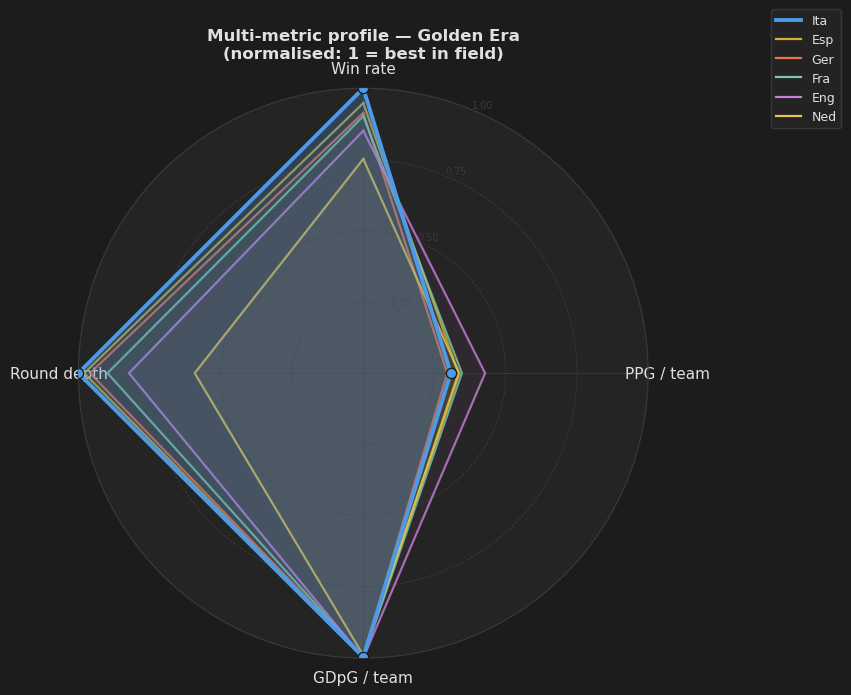

In [91]:
plot_radar(rankings, charts_dir="../charts/",
           country_name="Ita", top_n=6)